# Лабораторная работа №8. Метод Монте-Карло

**Задача:** проанализировать готовую программу, реализующую метод Монте-Карло, и
исследовать её — оценить точность и скорость сходимости в зависимости от числа испытаний.

**Выбранная задача из списка:** *оценка значения числа $\pi$*.


### Источник реализации

Базовая реализация метода взята из открытого учебного материала:

> Eric Marsden. *Monte Carlo methods: basic introduction.* risk-engineering.org courseware.
> URL: https://risk-engineering.org/notebook/monte-carlo-pi.html
> Лицензия: Creative Commons Attribution-ShareAlike 4.0 (CC BY-SA 4.0).

Код метода адаптирован самостоятельно (векторизация на NumPy, оформление экспериментов
и статистическая обработка результатов выполнены автором работы).

## 1. Теоретическое обоснование

Рассмотрим квадрат $[-1, 1]^2$ и вписанную в него окружность радиуса $1$.

- площадь круга: $S_{\text{круг}} = \pi r^2 = \pi$;
- площадь квадрата: $S_{\text{квадрат}} = 2^2 = 4$;
- отношение площадей: $S_{\text{круг}} / S_{\text{квадрат}} = \pi / 4$.

Если случайно и равномерно «бросать» точки в квадрат, то доля точек, попавших внутрь круга
($x^2 + y^2 \le 1$), при большом числе испытаний $N$ стремится к $\pi/4$. Отсюда:

$$\pi \approx 4 \cdot \frac{k}{N},$$

где $k$ — число точек, попавших в круг. Это пример геометрической вероятности
(вариант задачи Бюффона).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

PI = np.pi
print("Истинное значение pi =", PI)

Истинное значение pi = 3.141592653589793


## 2. Базовая реализация метода

Реализация повторяет логику источника (точки в квадрате $[-1,1]^2$, проверка
$x^2+y^2 \le 1$), но векторизована средствами NumPy для скорости.

In [2]:
def estimate_pi(n, rng):
    # Оценка pi по n испытаниям. rng — генератор np.random.Generator.
    x = rng.uniform(-1, 1, n)
    y = rng.uniform(-1, 1, n)
    inside = (x*x + y*y) <= 1.0
    k = np.count_nonzero(inside)
    return 4.0 * k / n

rng = np.random.default_rng(42)
for n in [100, 10_000, 1_000_000]:
    est = estimate_pi(n, rng)
    print(f"N = {n:>9}:  pi ~= {est:.6f},  |ошибка| = {abs(est-PI):.6f}")

N =       100:  pi ~= 3.120000,  |ошибка| = 0.021593
N =     10000:  pi ~= 3.128400,  |ошибка| = 0.013193
N =   1000000:  pi ~= 3.142144,  |ошибка| = 0.000551


## 3. Геометрическая иллюстрация

Покажем точки внутри и вне круга — это визуальная проверка корректности метода.

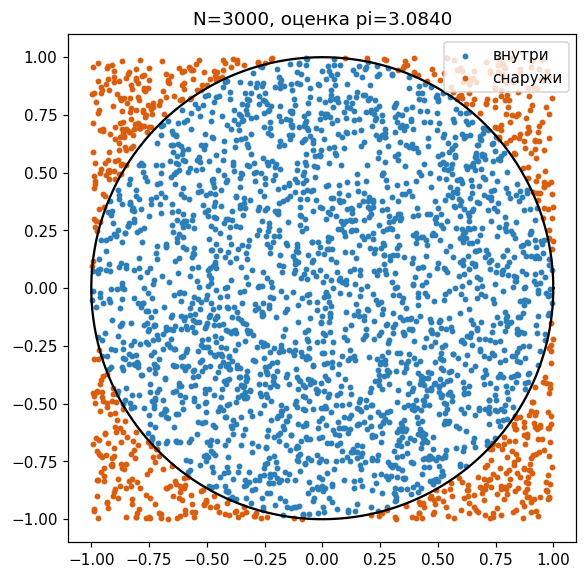

In [3]:
rng = np.random.default_rng(7)
n = 3000
x = rng.uniform(-1, 1, n)
y = rng.uniform(-1, 1, n)
inside = (x*x + y*y) <= 1.0
est = 4.0 * np.count_nonzero(inside) / n

plt.figure(figsize=(6, 6))
plt.scatter(x[inside],  y[inside],  s=8, c="#2c7fb8", label="внутри")
plt.scatter(x[~inside], y[~inside], s=8, c="#d95f0e", label="снаружи")
t = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(t), np.sin(t), "k", lw=1.5)
plt.gca().set_aspect("equal")
plt.title(f"N={n}, оценка pi={est:.4f}")
plt.legend(loc="upper right")
plt.show()

## 4. Эксперимент 1. Сходимость одиночных прогонов

Построим «бегущую» оценку $\pi$ по мере роста числа испытаний для нескольких
значений `seed`. Видно, что разные прогоны колеблются вокруг истинного значения, и
амплитуда колебаний убывает с ростом $N$.

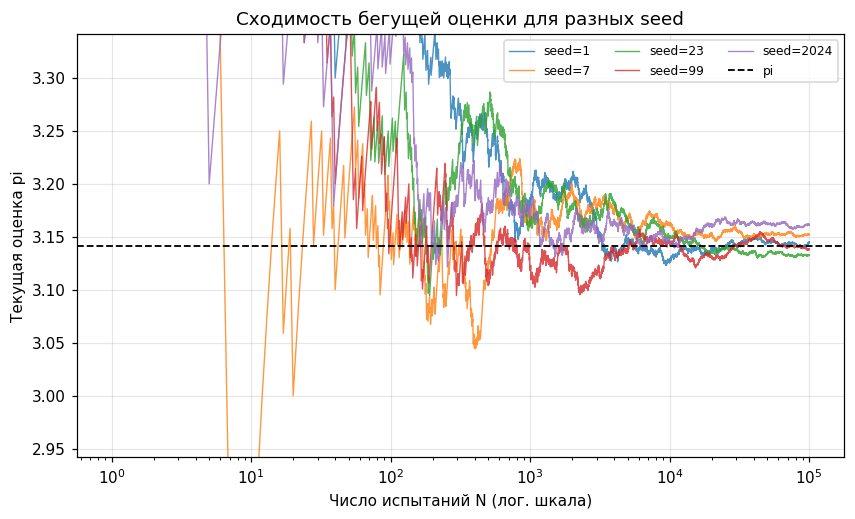

In [4]:
n_max = 100_000
plt.figure(figsize=(9, 5))
for s in (1, 7, 23, 99, 2024):
    g = np.random.default_rng(s)
    x = g.uniform(-1, 1, n_max)
    y = g.uniform(-1, 1, n_max)
    inside = (x*x + y*y) <= 1.0
    running = 4.0 * np.cumsum(inside) / np.arange(1, n_max + 1)
    plt.plot(np.arange(1, n_max + 1), running, lw=0.9, alpha=0.8, label=f"seed={s}")
plt.axhline(PI, color="k", ls="--", lw=1.2, label="pi")
plt.xscale("log"); plt.ylim(PI-0.2, PI+0.2)
plt.xlabel("Число испытаний N (лог. шкала)"); plt.ylabel("Текущая оценка pi")
plt.title("Сходимость бегущей оценки для разных seed")
plt.legend(ncol=3, fontsize=8); plt.grid(alpha=0.3)
plt.show()

## 5. Эксперимент 2. Статистика и скорость сходимости

Для каждого $N$ выполним $R$ независимых прогонов и оценим средний модуль ошибки и
эмпирическое СКО. Сравним с теоретическим значением.

**Теория.** Оценка $\hat\pi = 4k/N$, где $k \sim \mathrm{Binom}(N, p)$, $p = \pi/4$.
Тогда $\mathrm{Var}(\hat\pi) = 16\,p(1-p)/N$, и стандартное отклонение

$$\sigma(\hat\pi) = 4\sqrt{\frac{p(1-p)}{N}} = \frac{1{,}642}{\sqrt{N}}.$$

То есть ошибка убывает как $O(1/\sqrt{N})$: чтобы добавить один верный знак,
число испытаний нужно увеличить в 100 раз.

In [5]:
Ns = [10, 30, 100, 300, 1000, 3000, 10_000, 30_000,
      100_000, 300_000, 1_000_000, 2_000_000]
R = 100
rng = np.random.default_rng(12345)

print(f"{'N':>9} | {'<оценка>':>9} | {'<|ошибка|>':>11} | {'эмп.СКО':>9} | {'теор.СКО':>9}")
print("-"*58)
emp_std, theo_std = [], []
for n in Ns:
    ests = np.array([estimate_pi(n, rng) for _ in range(R)])
    e = ests.std(ddof=1)
    t = 4.0*np.sqrt((PI/4)*(1-PI/4)/n)
    emp_std.append(e); theo_std.append(t)
    print(f"{n:>9} | {ests.mean():>9.5f} | {np.abs(ests-PI).mean():>11.5f} | {e:>9.5f} | {t:>9.5f}")

        N |  <оценка> |  <|ошибка|> |   эмп.СКО |  теор.СКО
----------------------------------------------------------
       10 |   3.22800 |     0.36570 |   0.45927 |   0.51930
       30 |   3.21733 |     0.23902 |   0.28151 |   0.29982
      100 |   3.12840 |     0.14274 |   0.17664 |   0.16422
      300 |   3.13240 |     0.06730 |   0.08101 |   0.09481
     1000 |   3.14476 |     0.04375 |   0.05122 |   0.05193
     3000 |   3.14599 |     0.02328 |   0.02818 |   0.02998
    10000 |   3.13523 |     0.01354 |   0.01614 |   0.01642
    30000 |   3.14077 |     0.00739 |   0.00914 |   0.00948
   100000 |   3.14244 |     0.00384 |   0.00479 |   0.00519
   300000 |   3.14169 |     0.00230 |   0.00293 |   0.00300
  1000000 |   3.14117 |     0.00147 |   0.00180 |   0.00164
  2000000 |   3.14157 |     0.00093 |   0.00116 |   0.00116


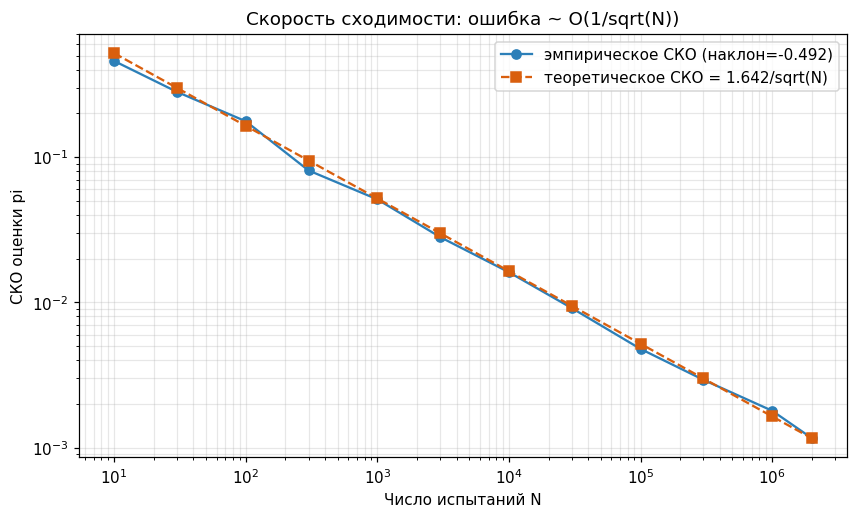

Измеренный наклон в log-log: -0.492  (теория: -0.5)


In [6]:
Ns_a = np.array(Ns, float)
emp = np.array(emp_std); theo = np.array(theo_std)
slope, _ = np.polyfit(np.log10(Ns_a), np.log10(emp), 1)

plt.figure(figsize=(9, 5))
plt.loglog(Ns_a, emp,  "o-", color="#2c7fb8", label=f"эмпирическое СКО (наклон={slope:.3f})")
plt.loglog(Ns_a, theo, "s--", color="#d95f0e", label="теоретическое СКО = 1.642/sqrt(N)")
plt.xlabel("Число испытаний N"); plt.ylabel("СКО оценки pi")
plt.title("Скорость сходимости: ошибка ~ O(1/sqrt(N))")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.show()
print(f"Измеренный наклон в log-log: {slope:.3f}  (теория: -0.5)")

## 6. Эксперимент 3. Влияние генератора случайных чисел

Сравним обычный псевдослучайный генератор (PCG64) с квазислучайной
последовательностью Соболя (low-discrepancy). Последовательность Соболя заполняет
квадрат равномернее и даёт сходимость, близкую к $O(1/N)$, что существенно точнее
при тех же $N$.

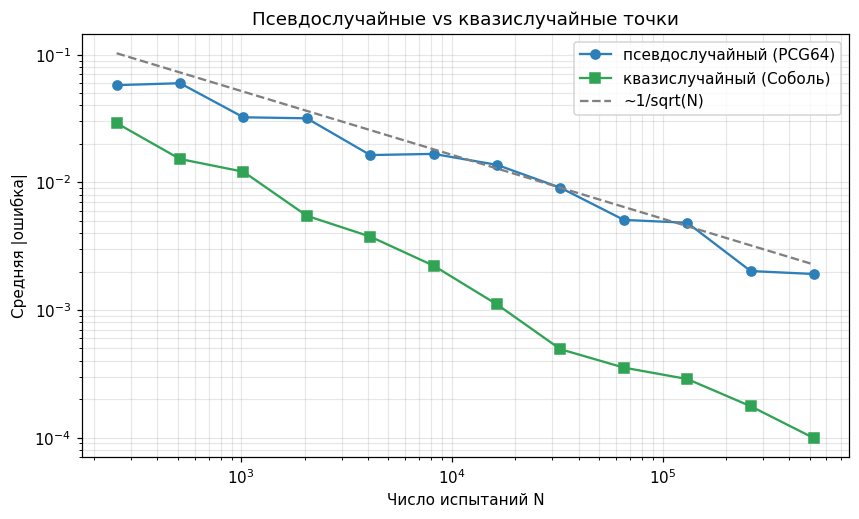

In [7]:
from scipy.stats import qmc

def pi_sobol(n, seed):
    s = qmc.Sobol(d=2, scramble=True, seed=seed)
    p = s.random(n) * 2 - 1            # точки в [-1, 1]^2
    inside = (p[:,0]**2 + p[:,1]**2) <= 1.0
    return 4.0 * np.count_nonzero(inside) / n

powers = range(8, 20)
Ns_q = [2**p for p in powers]
rng = np.random.default_rng(2024)
pe, qe = [], []
for n in Ns_q:
    pe.append(np.abs(np.array([estimate_pi(n, rng) for _ in range(20)]) - PI).mean())
    qe.append(np.abs(np.array([pi_sobol(n, s) for s in range(20)]) - PI).mean())

Ns_q = np.array(Ns_q, float)
plt.figure(figsize=(9, 5))
plt.loglog(Ns_q, pe, "o-", color="#2c7fb8", label="псевдослучайный (PCG64)")
plt.loglog(Ns_q, qe, "s-", color="#31a354", label="квазислучайный (Соболь)")
plt.loglog(Ns_q, 1.642/np.sqrt(Ns_q), "--", color="gray", label="~1/sqrt(N)")
plt.xlabel("Число испытаний N"); plt.ylabel("Средняя |ошибка|")
plt.title("Псевдослучайные vs квазислучайные точки")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.show()

## 7. Выводы

1. **Корректность.** Метод даёт несмещённую оценку $\pi$: при $N=10^6$ ошибка
   составляет порядка $10^{-3}$.
2. **Скорость сходимости — $O(1/\sqrt{N})$.** Измеренный наклон зависимости СКО от $N$
   в логарифмических координатах ($\approx -0{,}5$) совпадает с теоретическим, а
   эмпирическое СКО практически ложится на кривую $1{,}642/\sqrt{N}$.
3. **Цена точности.** Из-за медленной сходимости для получения каждого нового
   верного знака требуется в 100 раз больше испытаний. Поэтому для одно- и двумерных
   задач метод проигрывает детерминированным квадратурам; его преимущество —
   независимость скорости $O(1/\sqrt{N})$ от размерности задачи.
4. **Роль генератора.** Замена псевдослучайного генератора на квазислучайную
   последовательность Соболя заметно ускоряет сходимость (выигрыш в точности растёт
   с $N$), не меняя самого алгоритма.

*Источник базовой реализации: E. Marsden, risk-engineering.org, CC BY-SA 4.0.*